## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 – ошибки MSE**<0.034** на скорости обучения **0.001** на **10-й эпохе**.

## Импорт библиотек


In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [2]:
def ae_on_epoch_end(epoch, logs):
    print('________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    # Задание числа пикселей на дюйм
    plt.figure(dpi=100)

    # Предсказание енкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0,],predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение. Без него рисунок не отрисуется
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():
  # Получение названий всех картинок
  paths = glob.glob('*.jpg')

  # Удаление всех картинок по полученным путям
  for p in paths:
    os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [4]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
# Нормировка
X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

In [6]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

## Создание модели и обучение

In [7]:
# Ваше решение
# Энкодер
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), padding='same', activation='relu')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)

# 2-мерное скрытое пространство
latent = Dense(2, name='latent_space')(x)

encoder = Model(input_img, latent, name='encoder')


In [8]:
# Вход декодера — двумерное скрытое пространство
decoder_input = Input(shape=(2,))

x = Dense(7 * 7 * 64, activation='relu')(decoder_input)
# преобразование в многомерный тензор 7x7x64
x = Reshape((7, 7, 64))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)
# Создание модели декодера
decoder = Model(decoder_input, decoder_output, name='decoder')



In [9]:
# На вход автокодировщика подается изображение
autoencoder_input = input_img
encoded = encoder(autoencoder_input)# encoder сжимает картинку в 2 числа
decoded = decoder(encoded)# Decoder получает 2-мерное скрытое представление

# вход -> encoder -> decoder -> восстановленное изображение
autoencoder = Model(autoencoder_input, decoded, name='autoencoder')

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       420,994 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,467 (1.86 MB)

 Trainable params: 486,083 (1.85 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1492________________________
*** ЭПОХА: 1, loss: 0.10097008943557739 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


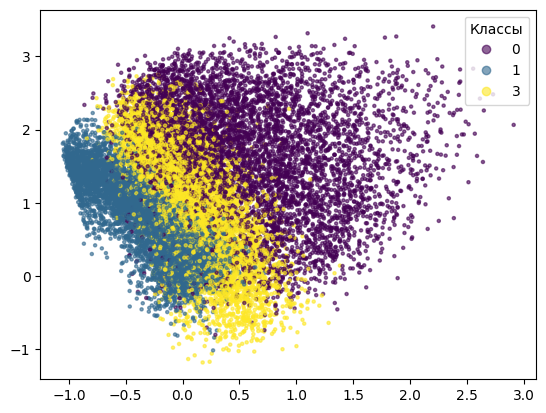

74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - loss: 0.1010
Epoch 2/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0571________________________
*** ЭПОХА: 2, loss: 0.053661152720451355 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


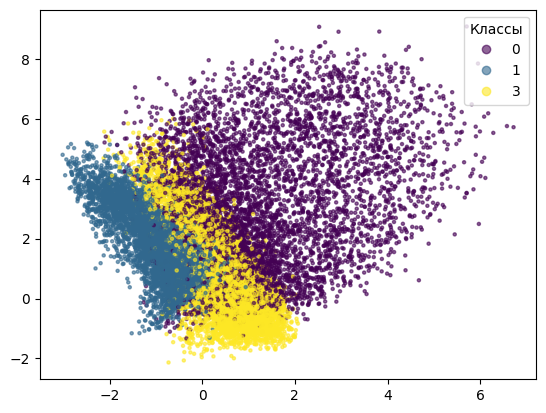

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0537
Epoch 3/10
71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0462________________________
*** ЭПОХА: 3, loss: 0.04356921464204788 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


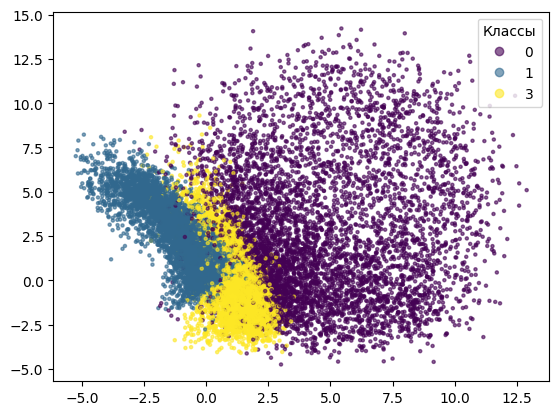

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0436
Epoch 4/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0366________________________
*** ЭПОХА: 4, loss: 0.03566128760576248 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


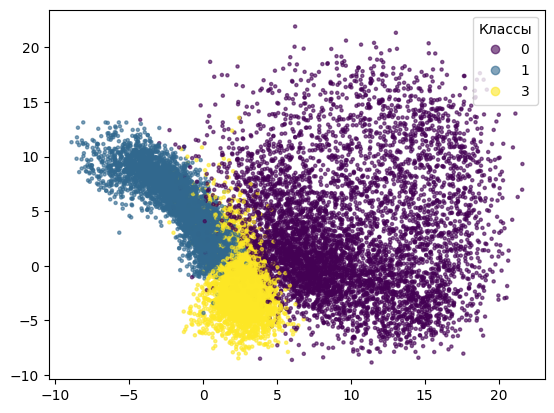

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0357
Epoch 5/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0335________________________
*** ЭПОХА: 5, loss: 0.03318016231060028 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


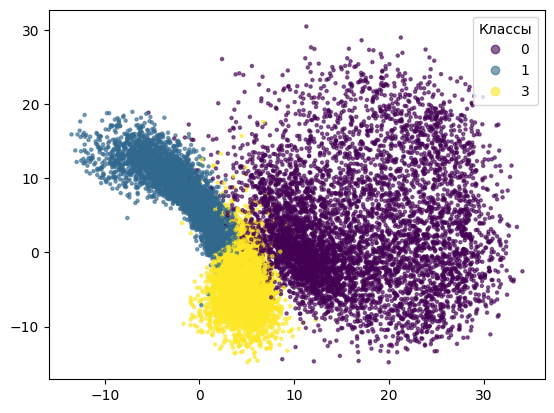

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.0332
Epoch 6/10
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0321________________________
*** ЭПОХА: 6, loss: 0.03176092356443405 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


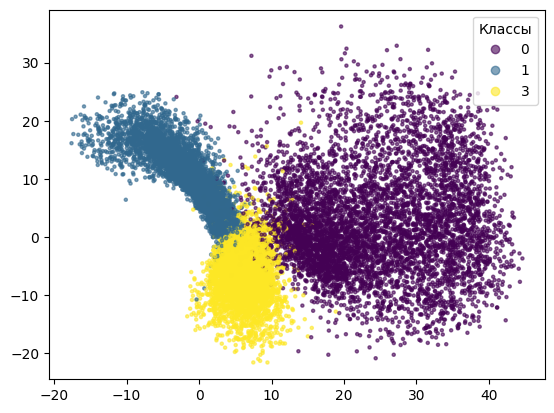

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0318
Epoch 7/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0305________________________
*** ЭПОХА: 7, loss: 0.030652813613414764 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


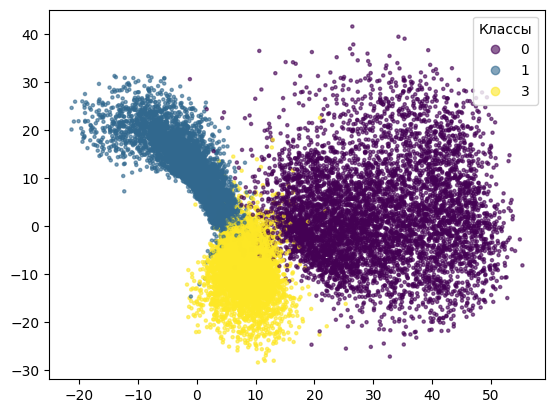

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0307
Epoch 8/10
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0304________________________
*** ЭПОХА: 8, loss: 0.030400680378079414 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


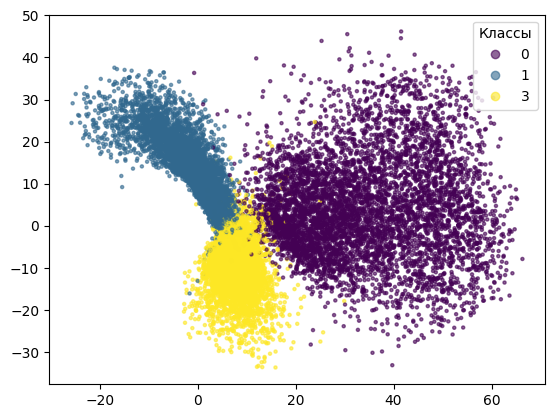

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0304
Epoch 9/10
71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0305________________________
*** ЭПОХА: 9, loss: 0.030389951542019844 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


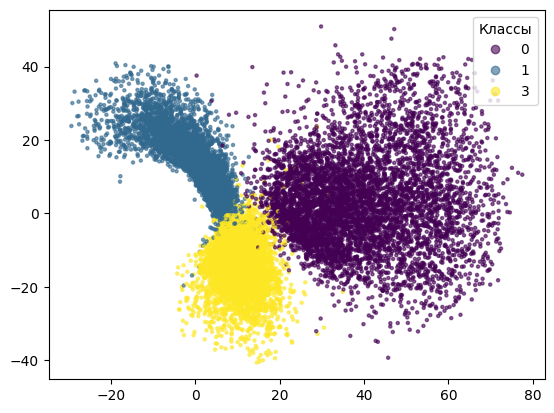

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0304
Epoch 10/10
71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0301________________________
*** ЭПОХА: 10, loss: 0.029972290620207787 ***
________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


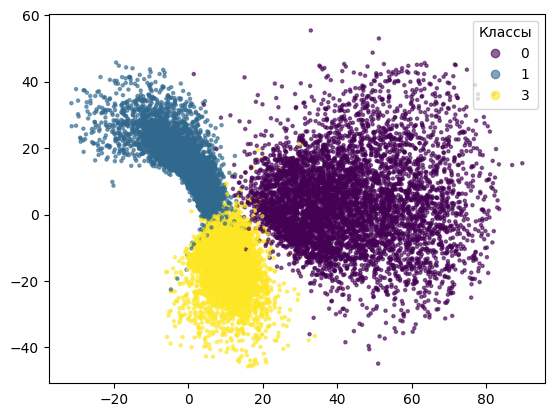

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0300


In [11]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    callbacks=[ae_callback]
)

In [13]:
final_loss = history.history['loss'][-1]
print("Final MSE:", final_loss)

Final MSE: 0.029972290620207787
